# Classificació salaris

Anem a explorar un dataset de dades clàssic: https://archive.ics.uci.edu/dataset/2/adult

El target és categòric: guanya més de 50k $ o menys.  

In [1]:
import pandas as pd

features=("age","workclass","fnlwgt","educacion","education-num","marital-status","occupation","relationship","race","sex","capital-gain","capital-loss","hours-per-week","country","target")
train_url="https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
data = pd.read_csv(train_url, names=features, sep=', ', engine='python')


In [2]:
data.head()

,age,workclass,fnlwgt,educacion,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
data.describe(include='all')

,age,workclass,fnlwgt,educacion,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,country,target
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   educacion       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  country         32561 non-null  str  
 14  target          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [9]:
print(data.isna().any())
data["workclass"].value_counts()

age               False
workclass         False
fnlwgt            False
educacion         False
education-num     False
marital-status    False
occupation        False
relationship      False
race              False
sex               False
capital-gain      False
capital-loss      False
hours-per-week    False
country           False
target            False
dtype: bool


workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

<Axes: xlabel='target'>

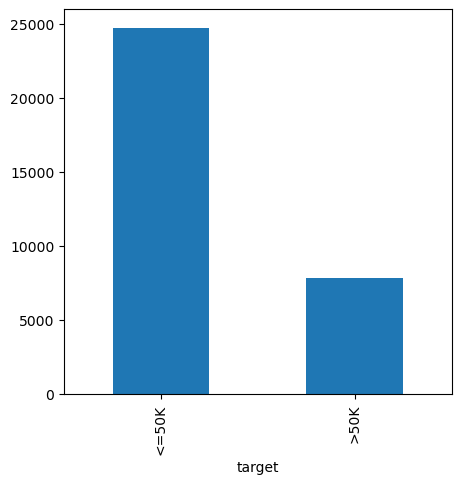

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,5))
data["target"].value_counts().plot(kind="bar")

Les dades aparentment estan bé i no falten dades però el que passa és que hi ha `?` en algunes variables categòriques. Com que no estem fen un EDA rigorós anem a considerar que no saber, per exemple, l'ocupació també és una informació rellevant per a la predicció. 

## Model basat en arbres de decisió

Anem a fer una classificació binària amb algorismes de la familia dels arbres de decisió.

Com que hi ha variables categòriques amb moltes classes, tal vegada no té sentit fer `One Hot Encoding`. es poden convertir en numériques si volem fer un `Random Forest` o inclús utilitzar `HistGradientBoostingClassifier` Que ja hem vist que és molt eficient i amés accepta variables categòriques sense transformació. Farem la transformació a categoric i entrenarem amb el dataset amb poques modificacions. 


In [52]:
df = data.copy()

# 1. Seleccionem totes les columnes que són de tipus object o string
columnes_string = df.select_dtypes(include=['object', 'string']).columns

# 2. Les convertim a tipus 'category' de cop
df[columnes_string] = df[columnes_string].astype('category')


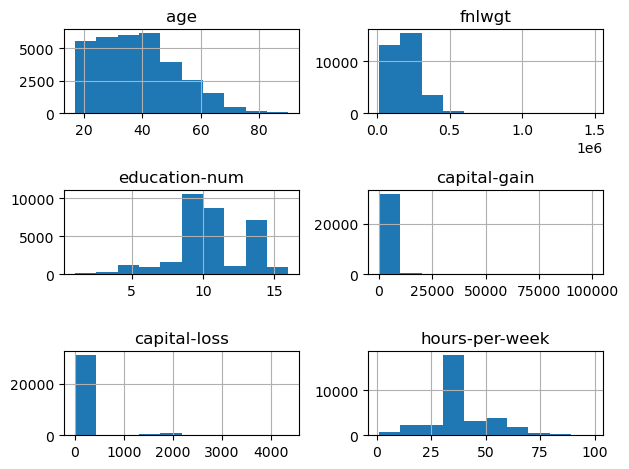

In [25]:
df.hist()
plt.tight_layout ()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = df.drop(columns=["target"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import HistGradientBoostingClassifier
model = HistGradientBoostingClassifier()
model.fit(X_train, y_train)


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dty

Score: 0.881467833563642
Accuracy: 0.881467833563642
Confusion Matrix: [[4678  264]
 [ 508 1063]]
Precision: 0.8010550113036925
Recall: 0.6766390833863781
F1 Score: 0.7336093857832988


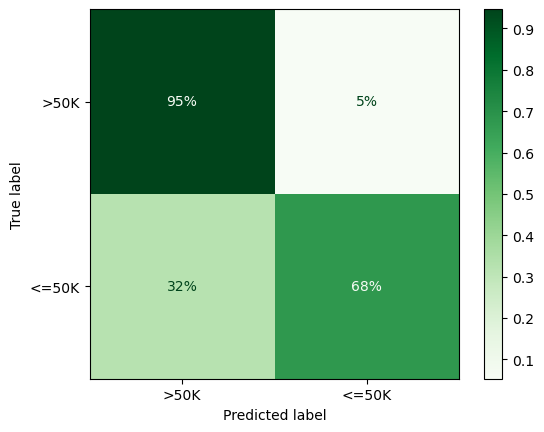

In [23]:

score = model.score(X_test, y_test)
print(f"Score: {score}")
print(f"Accuracy: {accuracy_score(y_test, model.predict(X_test))}")
print(f"Confusion Matrix: {confusion_matrix(y_test, model.predict(X_test))}")
print(f"Precision: {precision_score(y_test, model.predict(X_test), pos_label='>50K')}")
print(f"Recall: {recall_score(y_test, model.predict(X_test), pos_label='>50K')}")
print(f"F1 Score: {f1_score(y_test, model.predict(X_test), pos_label='>50K')}")

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap=plt.cm.Greens, 
    normalize='true',
    values_format='.0%',
    display_labels=[">50K", "<=50K"] 
)
plt.show()


## Model basat en Regressió Logística

En aquest cas anem a enfocar el problema com una regressió. Optem per `SGDClassifier`perquè és la versió amb descens de gradient de la regressió logística. 

Dibuixarem les correlacions entre variables per veure si hi ha algunes molt correlacionades. 

Anem a tenir problemes amb les variables categòriques, ja que no serveixen per a una fórmula matemàtica i la transformació en números directament por tenir el problema de donar més valor a unes classes que a altres, per tant, farem un `One Hot Encoding` primer.

Quedaran moltes dimensions, així que valorarem fer un regularització `Ridge` o `Lasso` per reduïr la dimensionalitat. 

També tindrem problemes amb les variables no normalitzades, can escalar-les. 

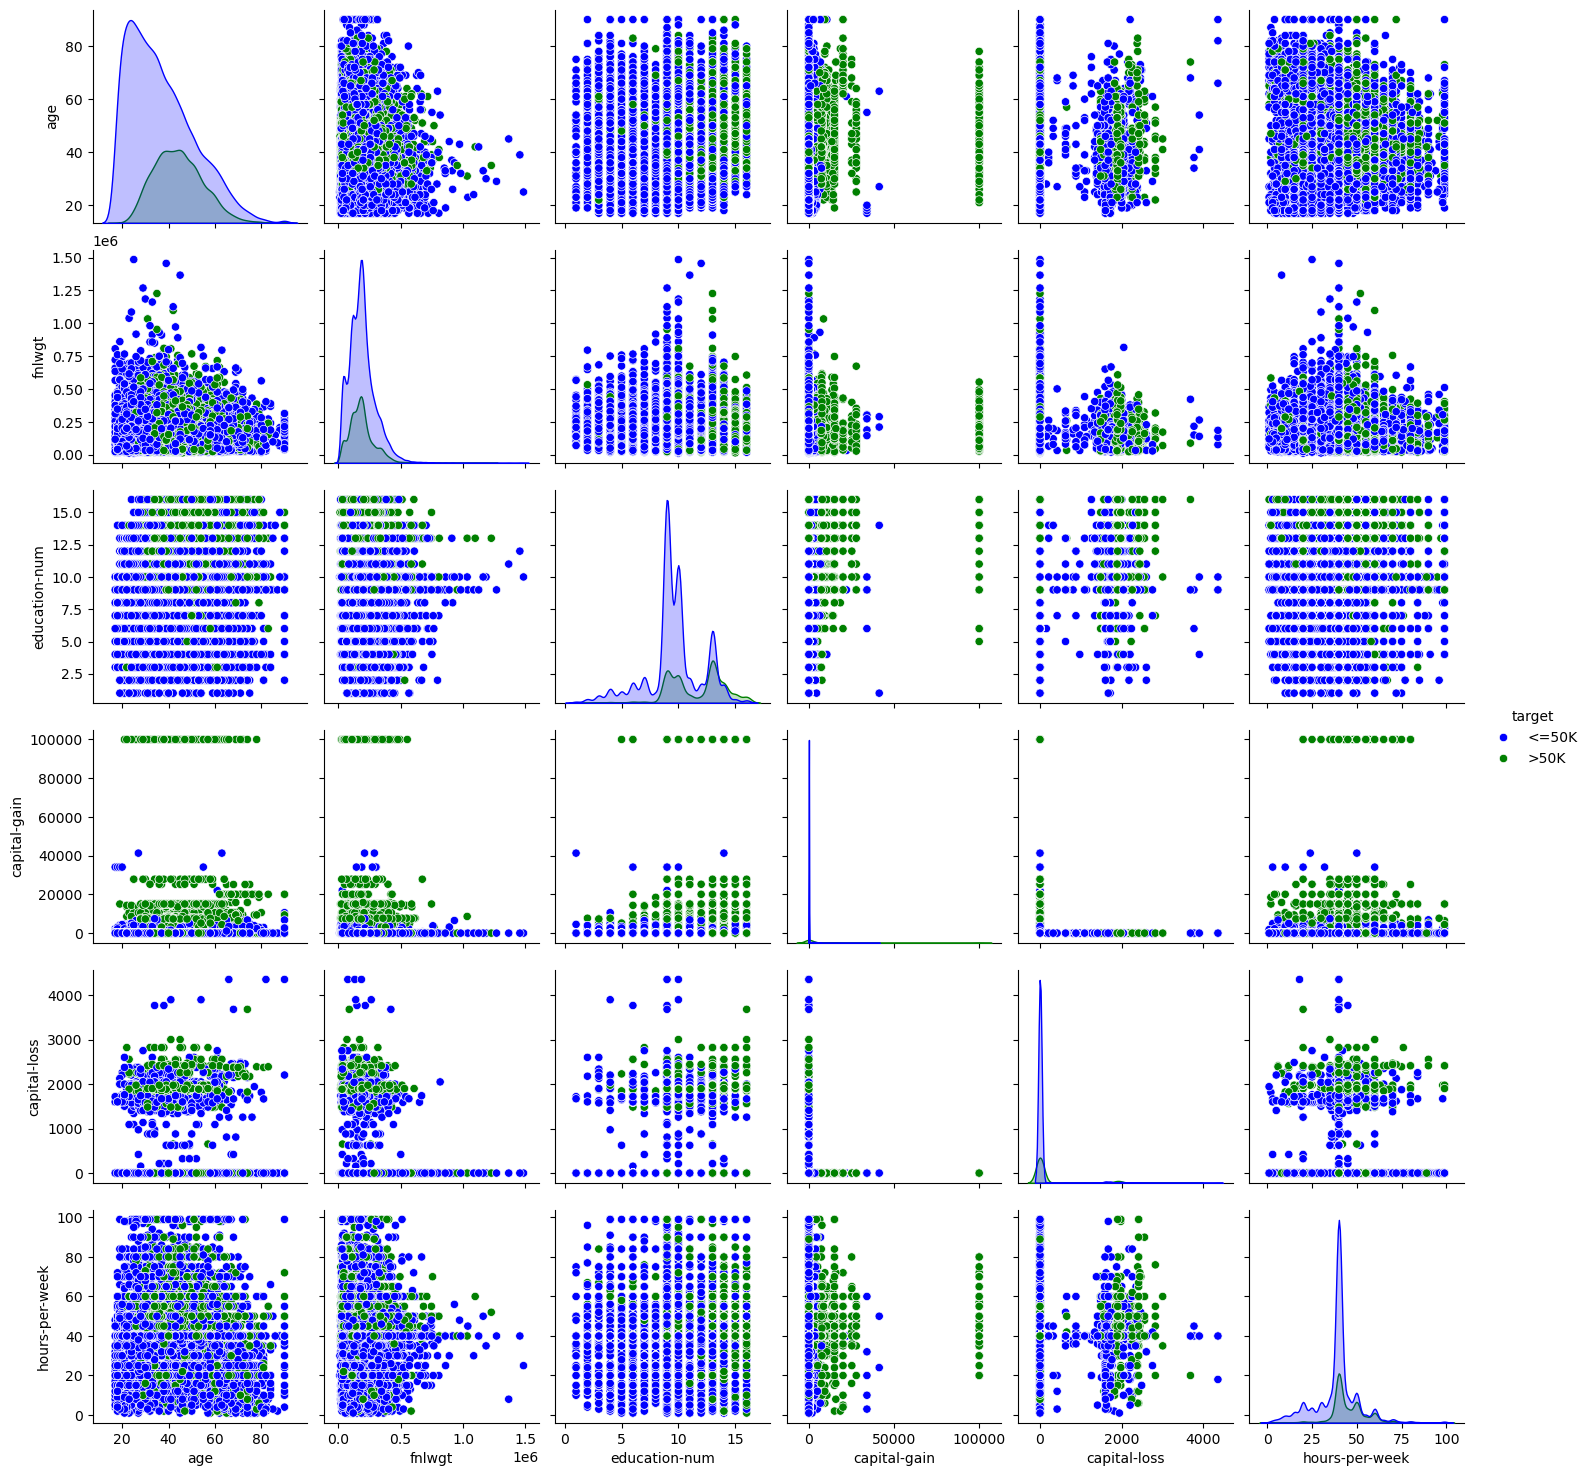

In [38]:

import seaborn as sns
sns.pairplot(data=df, hue="target", palette={'>50K':'green', '<=50K':'blue'})

<Axes: >

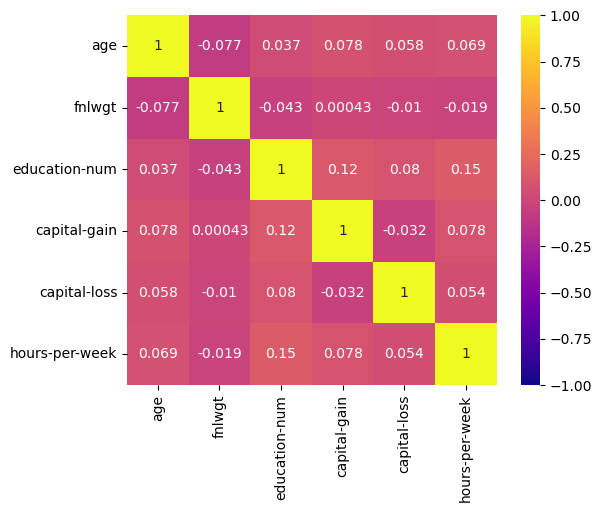

In [31]:
# 1. Separar columnes numèriques (incloses les dummies)
df_num = df.select_dtypes(include=['int64', 'float64', 'uint8'])

# 2. Calcular la correlació només sobre aquestes
corr_matrix = df_num.corr()

# 3. Dibuixar el heatmap
sns.heatmap(corr_matrix, square=True, annot=True, vmin=-1, vmax=1, cmap='plasma')

S'observa que no hi ha correlació lineal entre les variables i que algunes sí tenen correlació amb el `target`.

Com que tenim moltes variables categòriques el que més sentit té és mostrar la `Mutual Information`.

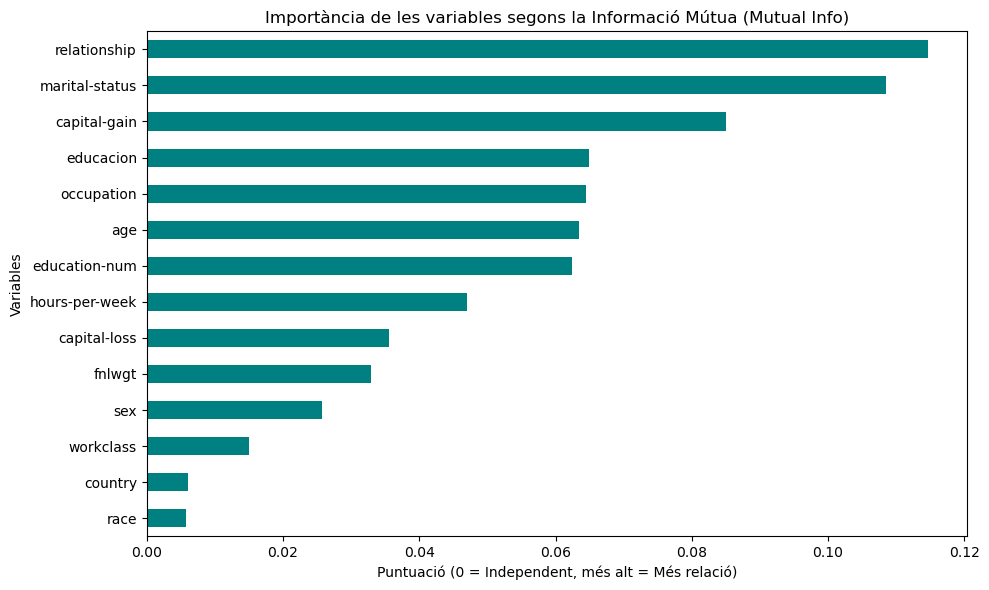

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# 1. Separem les variables predictores (X) del Target (y)
X = df.drop(columns=['target'])
y = df['target']

# 2. Identifiquem quines columnes són categòriques
cat_cols = X.select_dtypes(include=['object', 'category']).columns

# Creem una màscara booleana per dir a la funció quina columna és discreta (True) i quina contínua (False)
discrete_features_mask = [col in cat_cols for col in X.columns]

# 3. Transformem les variables categòriques a nombres enters (requisit de scikit-learn)
X_encoded = X.copy()
oe = OrdinalEncoder()
X_encoded[cat_cols] = oe.fit_transform(X_encoded[cat_cols].astype(str))

# Si el target també és text (string), el convertim a enter
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. Calculem la Informació Mútua
mi_scores = mutual_info_classif(
    X_encoded, 
    y_encoded, 
    discrete_features=discrete_features_mask, 
    random_state=42
)

# Ho organitzem en una sèrie de Pandas de major a menor importància
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# 5. Dibuixem un gràfic de barres horitzontals molt visual
plt.figure(figsize=(10, 6))
mi_scores.plot(kind='barh', color='teal')
plt.title("Importància de les variables segons la Informació Mútua (Mutual Info)")
plt.xlabel("Puntuació (0 = Independent, més alt = Més relació)")
plt.ylabel("Variables")
plt.gca().invert_yaxis() # Posa la variable més important a la part superior
plt.tight_layout()
plt.show()

In [39]:
df["relationship"].value_counts()

relationship
Husband           13193
Not-in-family      8305
Own-child          5068
Unmarried          3446
Wife               1568
Other-relative      981
Name: count, dtype: int64

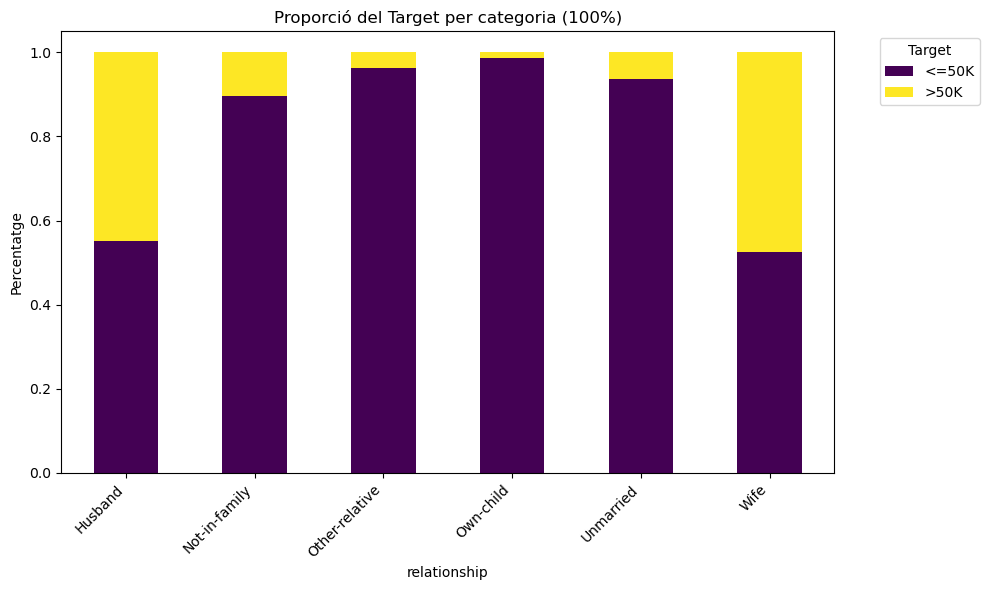

In [45]:

import matplotlib.pyplot as plt


prop_df = pd.crosstab(df['relationship'], df['target'], normalize='index')

prop_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Proporció del Target per categoria (100%)')
plt.ylabel('Percentatge')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Sembla que `Relationship` és el que més informació dona respecte al salari. Per algún motiu les persones casades, ja siguen dones o marits tenen més percentatge de persones que cobren per damunt del 50k. 

En qualsevol cas, altres variables tenen prou importància i serviran per a afinar la predicció. 

Després de l'anàlisi fem la conversió and `One Hot Encoding` i preparem el model:

In [ ]:
df = data.copy()

# 1. Seleccionem totes les columnes que són de tipus object o string
columnes_string = df.select_dtypes(include=['object', 'string']).columns

# 2. Les convertim a tipus 'category' de cop
df[columnes_string] = df[columnes_string].astype('category')



df_backup = df.copy()
df_backup = df_backup.drop(columns=['target'])  # Eliminem la columna target per a la codificació one-hot
df_onehot = pd.get_dummies(df_backup, columns=df_backup.select_dtypes(include=['category']).columns, prefix='cat', prefix_sep='_' , drop_first=True)
df_onehot.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,cat_Federal-gov,cat_Local-gov,cat_Never-worked,cat_Private,...,cat_Portugal,cat_Puerto-Rico,cat_Scotland,cat_South,cat_Taiwan,cat_Thailand,cat_Trinadad&Tobago,cat_United-States,cat_Vietnam,cat_Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [55]:
df_standardized = df_onehot.copy()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_standardized[df_standardized.columns] = scaler.fit_transform(df_standardized[df_standardized.columns])
df_standardized.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,cat_Federal-gov,cat_Local-gov,cat_Never-worked,cat_Private,...,cat_Portugal,cat_Puerto-Rico,cat_Scotland,cat_South,cat_Taiwan,cat_Thailand,cat_Trinadad&Tobago,cat_United-States,cat_Vietnam,cat_Yugoslavia
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429,-0.174295,-0.262097,-0.014664,-1.516792,...,-0.033729,-0.059274,-0.019201,-0.049628,-0.039607,-0.023518,-0.024163,0.340954,-0.045408,-0.022173
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153,-0.174295,-0.262097,-0.014664,-1.516792,...,-0.033729,-0.059274,-0.019201,-0.049628,-0.039607,-0.023518,-0.024163,0.340954,-0.045408,-0.022173
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429,-0.174295,-0.262097,-0.014664,0.659286,...,-0.033729,-0.059274,-0.019201,-0.049628,-0.039607,-0.023518,-0.024163,0.340954,-0.045408,-0.022173
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429,-0.174295,-0.262097,-0.014664,0.659286,...,-0.033729,-0.059274,-0.019201,-0.049628,-0.039607,-0.023518,-0.024163,0.340954,-0.045408,-0.022173
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429,-0.174295,-0.262097,-0.014664,0.659286,...,-0.033729,-0.059274,-0.019201,-0.049628,-0.039607,-0.023518,-0.024163,-2.932948,-0.045408,-0.022173


In [63]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelEncoder

X = df_standardized
y = df['target']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)



clf = SGDClassifier(loss="log_loss", penalty="l2", max_iter=5)
clf.fit(X_train, y_train)



/home/jose/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",5
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if th

Accuracy: 0.8143712574850299
Confusion Matrix: [[4369  573]
 [ 636  935]]
Precision: 0.620026525198939
Recall: 0.5951623169955442
F1 Score: 0.6073400454693082


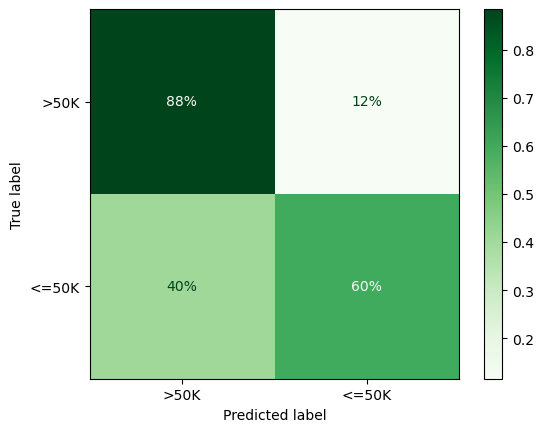

In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


print(f"Accuracy: {accuracy_score(y_test, clf.predict(X_test))}")
print(f"Confusion Matrix: {confusion_matrix(y_test, clf.predict(X_test))}")
print(f"Precision: {precision_score(y_test, clf.predict(X_test))}")
print(f"Recall: {recall_score(y_test, clf.predict(X_test))}")
print(f"F1 Score: {f1_score(y_test, clf.predict(X_test))}")

ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    cmap=plt.cm.Greens, 
    normalize='true',
    values_format='.0%',
    display_labels=[">50K", "<=50K"] 
)
plt.show()


Tot i que els models de *boosting* com XGBoost solen superar en precisió els algorismes lineals en dades tabulars gràcies a la seva capacitat per modelar relacions no lineals complexes, el `SGDClassifier` manté avantatges pràctics determinants en escenaris concrets. Concretament, destaca per la seva eficiència en entorns de *Big Data* mitjançant l'aprenentatge incremental per lots (`.partial_fit`), per oferir una interpretabilitat total basada en pesos lineals explícits, i per un consum mínim de recursos computacionals ideal per a sistemes amb restriccions de producció. Per tant, mentre que XGBoost s'erigeix com l'opció òptima per maximitzar l'encert en conjunts de dades estàndard, el model estocàstic esdevé una alternativa indispensable quan s'operen volums massius d'informació o s'exigeix una transparència analítica estricta.

> Exercici: Fer un anàlisi ANOVA per eliminar variables no rellevants abans de l'entrenament, fer un anàlisi amb SHAP per detectar les variables que més afecten. 

> Exercici: Fer una Pipeline per a fer les transformacions Anova, One-Hot, Estandarització, codificació de Y i entrenament. Fer que el Pipeline funcione també per a inferència. 

> Exercici: Fer un GridSearCV per trobar els hiperparàmetres millors per al SGDClassifier, fer que siga compatible amb la pipeline anterior. 

> Exercici: Implementar un `Early Stopping` al `SGDClassifier`. 

> Exercici: Fer un anàlisi de la compensació entre precisió i recall amb `decision_function` i la curva `ROC`. Interpreta l'enunciat per decidir el millor model en funció del que es vol predir. 

> Exercici: Avaluar si el dataset està descompensat (per exemple, un 90% d'una classe i un 10 d'una altra). Si és així, implementar una estratègia per solucionar-ho: modifica el paràmetre class_weight='balanced' al SGDClassifier o afegeix un pas de mostratge (com SMOTE) integrat dins de la Pipeline utilitzant la llibreria imbalanced-learn. Compara com afecta el Recall de la classe minoritària.

> Exercici: Utilitzant les prediccions del model, extreure i analitzar un llistat de les mostres on el model s'ha equivocat pitjor (els falsos positius més clars i els falsos negatius més evidents). Buscar patrons comuns en aquestes dades per entendre per què falla el model.

> Exercici: Un cop tingues el teu Pipeline optimitzat amb el GridSearchCV, desa l'objecte complet a un fitxer utilitzant la llibreria joblib. Després, crea un script independent (o una funció) que carregui aquest fitxer i simuli l'arribada d'una sola observació nova en format diccionari per obtenir la predicció i la seva probabilitat/score de manera automàtica.